## Truncamiento de datos para el modelo de TargetClassification

En este notebook vamos a realizar un truncamiento de datos para la primera parte de nuestro pipeline. 

Como podemos observar en nuestro corpus.json, disponemos de 1.2 millones de post en nuestro corpus de overwatch. 

Tanto para realizar una clasificacion con reglas lógicas aplicadas sobre TD-IDF de los datos, como para hacer un fine tuning de un modelo con transformers, no necesitamos una cantidad de datos tan inmensa.

Cabe decir que estos truncamientos no se van a realizar sobre el archivo original, por tanto si en un futuro necesitamos hacer un corte con una distribución distinta, se podrá volver siempre a los datos originales

Vamos a exibir dos muestras para visualizar mejor la tarea.

- Instancia de conversations.json

{"5wrk88": {"title": "Raisin\u2019 the tension", "num_comments": 0, "domain": "omegadimentioyt.tumblr.com", "timestamp": 1488326417, "subreddit": "Overwatch", "gilded": 0, "gildings": null, "stickied": false, "author_flair_text": ""}, "5wrk8a": {"title": "Why I'm not worried about new Bastion mains.", "num_comments": 1, "domain": "i.redd.it", "timestamp": 1488326418, "subreddit": "Overwatch", "gilded": 0, "gildings": null, "stickied": false, "author_flair_text": "Tracer"},

- Instancia de utterances.jsonl

{"id": "4zrtmv", "user": "stoDots", "root": "4zrtmv", "reply_to": null, "timestamp": 1472258282, "text": "So, I was having my usual thoughts on features that could possibly be cool to add to Overwatch, and Play of the Game came into mind and was thinking about how every hero in Overwatch has a set of unique highlight intros, and I thought maybe, just maybe if each hero could get a unique set of soundtracks that will play when they get a Play of the Game. I believe that this could add a bit of more variety when it comes to viewing POTGs and overall will just make it a more enjoyable experience. If something like this were to ever happen, I could imagine people being able to do things that would go in sync with the soundtrack, kind of like how D.Va has that one emote when she's out of her mech, and if timed properly when you use her ult, it'll synchronize with the explosion of her mech's explosion. Feel free to agree or disagree as this is just an idea that I randomly came up with.", "meta": {"score": 2, "top_level_comment": null, "retrieved_on": 1473083535, "gilded": 0, "gildings": null, "subreddit": "Overwatch", "stickied": false, "permalink": "/r/Overwatch/comments/4zrtmv/play_of_the_game_highlight_soundtrack_idea/", "author_flair_text": "Tracer"}}

Podemos observar que ambas instancias tiene recopilado un id, por tanto es posible realizar un truncamiento igualitario para ambos subconjuntos. Dandole consistencia a nuestros datos finales.

Además vamos a realizar este truncamiento quedandonos con los datos mas recientes.

Primero vamos a truncar el subconjunto de conversations.json, ya que aqui podemos realizar el punto de corte a seguir, debido a que en este dataset solo tenemos los titulos de los posts, y no los comentarios añadidos. Para la tarea de captar contexto y clasificar un nuevo post según nuestro target, es muy conveniente quedarnos con el titulo y el texto de cada post, y no con el texto de las contestaciones, ya que estas pueden no presentar contexto intrinseco alguno, ese contexto ya va proporcionado por el propio hilo.

In [1]:
import json
from datetime import datetime

INPUT_PATH = "D:\\TFM\\data\\Overwatch.corpus\\conversations.json"
OUTPUT_PATH = "D:\\TFM\\data\\Overwatch.corpus\\conversations_truncated.json"
TARGET_N = 300_000  # ajustable

def truncate_conversations_by_recency(input_path, output_path, target_n):
    with open(input_path, "r", encoding="utf-8") as f:
        convs = json.load(f)  # dict {conv_id: {title, timestamp, ...}}

    print(f"Total de posts original: {len(convs)}")

    # Ordenamos por timestamp descendente (más reciente primero)
    sorted_items = sorted(
        convs.items(),
        key=lambda kv: kv[1].get("timestamp", 0),
        reverse=True
    )

    truncated_items = sorted_items[:target_n]
    truncated_dict = dict(truncated_items)

    # Sanity check: rango temporal cubierto por la muestra
    timestamps = [meta.get("timestamp", 0) for _, meta in truncated_items]
    oldest = datetime.utcfromtimestamp(min(timestamps))
    newest = datetime.utcfromtimestamp(max(timestamps))
    print(f"Posts conservados: {len(truncated_dict)}")
    print(f"Rango temporal: {oldest} → {newest}")

    with open(output_path, "w", encoding="utf-8") as f:
        json.dump(truncated_dict, f, ensure_ascii=False)

    print(f"Guardado en: {output_path}")
    return truncated_dict

sampled_conv_ids = set(
    truncate_conversations_by_recency(INPUT_PATH, OUTPUT_PATH, TARGET_N).keys()
)

Total de posts original: 1257093
Posts conservados: 300000
Rango temporal: 2017-10-20 05:09:55 → 2018-10-31 23:59:24
Guardado en: D:\TFM\data\Overwatch.corpus\conversations_truncated.json


Perfecto! Ya tenemos truncados y guardados los últimos 300.000 posts mas recientes, ahora vamos a realizar la misma operación para utterances.jsonl

Vamos a quedarnos con las instancias que tengan un id asociado a nuestro conversations_truncates.json, para asi hacer la división en la misma linea temporal.

Además, como recorrer el archivo utterances.jsonl de 8gb tiene un coste computacional alto, vamos a quedarnos también con todos los comentarios asociados a los posts, aprovechando que en este paso vamos a tener que recorrer todo el archivo de uno en uno igualmente. Mas adelante en la preparación se filtrarán solo las descripciones de cada post, para esta parte del pipeline del proyecto

In [2]:
CONV_TRUNCATED_PATH = "D:\\TFM\\data\\Overwatch.corpus\\conversations_truncated.json"
UTTERANCES_PATH = "D:\\TFM\\data\\Overwatch.corpus\\utterances.jsonl"
OUTPUT_PATH = "D:\\TFM\\data\\Overwatch.corpus\\utterances_truncated.jsonl"

def load_sampled_ids(conv_truncated_path):
    with open(conv_truncated_path, "r", encoding="utf-8") as f:
        convs = json.load(f)
    return set(convs.keys())

def truncate_utterances(utterances_path, output_path, sampled_ids):
    n_seen = 0
    n_kept = 0
    n_posts_kept = 0

    with open(utterances_path, "r", encoding="utf-8") as fin, \
         open(output_path, "w", encoding="utf-8") as fout:

        for line in fin:
            n_seen += 1
            utt = json.loads(line)

            if utt.get("root") in sampled_ids:
                fout.write(line)  # escribimos la línea cruda tal cual, sin reserializar
                n_kept += 1
                if utt.get("reply_to") is None:
                    n_posts_kept += 1

            if n_seen % 1_000_000 == 0:
                print(f"Procesadas {n_seen:,} líneas... conservadas: {n_kept:,}")

    print(f"\nTotal líneas procesadas: {n_seen:,}")
    print(f"Total utterances conservadas (posts+comentarios): {n_kept:,}")
    print(f"De ellas, posts: {n_posts_kept:,}")
    print(f"Guardado en: {output_path}")

sampled_ids = load_sampled_ids(CONV_TRUNCATED_PATH)
print(f"Ids de conversación cargados: {len(sampled_ids):,}")

truncate_utterances(UTTERANCES_PATH, OUTPUT_PATH, sampled_ids)

Ids de conversación cargados: 300,000
Procesadas 1,000,000 líneas... conservadas: 184,992
Procesadas 2,000,000 líneas... conservadas: 300,000
Procesadas 3,000,000 líneas... conservadas: 300,000
Procesadas 4,000,000 líneas... conservadas: 300,000
Procesadas 5,000,000 líneas... conservadas: 300,000
Procesadas 6,000,000 líneas... conservadas: 300,000
Procesadas 7,000,000 líneas... conservadas: 300,000
Procesadas 8,000,000 líneas... conservadas: 300,000
Procesadas 9,000,000 líneas... conservadas: 300,000
Procesadas 10,000,000 líneas... conservadas: 300,000
Procesadas 11,000,000 líneas... conservadas: 300,000
Procesadas 12,000,000 líneas... conservadas: 518,264
Procesadas 13,000,000 líneas... conservadas: 1,516,986
Procesadas 14,000,000 líneas... conservadas: 2,516,783
Procesadas 15,000,000 líneas... conservadas: 3,516,744

Total líneas procesadas: 15,458,922
Total utterances conservadas (posts+comentarios): 3,975,655
De ellas, posts: 300,000
Guardado en: D:\TFM\data\Overwatch.corpus\uttera

como pequeña observacion para futuras manipulaciones, observamos que entre los 2M y 11M de primeras lineas, las utterances guardadas no han subido. Esto indica que el archivo .jsonl original no esta ordenado ni por timestamp ni pero ids

vamos a realizar una comprobación de que efectivamente los ids conservados en utterances y conversations son iguales

In [3]:
CONV_TRUNCATED_PATH = "D:\\TFM\\data\\Overwatch.corpus\\conversations_truncated.json"
UTT_TRUNCATED_PATH = "D:\\TFM\\data\\Overwatch.corpus\\utterances_truncated.jsonl"

# 1. Ids esperados desde conversations_truncated.json
with open(CONV_TRUNCATED_PATH, "r", encoding="utf-8") as f:
    conv_ids = set(json.load(f).keys())

print(f"Ids en conversations_truncated.json: {len(conv_ids):,}")

# 2. Recorremos utterances_truncated.jsonl y separamos posts vs comentarios
post_ids = []
all_roots = set()
n_total = 0

with open(UTT_TRUNCATED_PATH, "r", encoding="utf-8") as f:
    for line in f:
        utt = json.loads(line)
        n_total += 1
        all_roots.add(utt["root"])
        if utt.get("reply_to") is None:
            post_ids.append(utt["id"])

post_ids_set = set(post_ids)

print(f"Total utterances en el fichero truncado: {n_total:,}")
print(f"Posts encontrados (reply_to is None): {len(post_ids):,}")
print(f"Posts únicos (set): {len(post_ids_set):,}")

# 3. Comprobaciones clave
duplicados = len(post_ids) - len(post_ids_set)
faltantes_en_utt = conv_ids - post_ids_set      # ids en conversations pero sin post en utterances
sobrantes_en_utt = post_ids_set - conv_ids      # posts en utterances que no estaban en conversations
roots_fuera_de_conv = all_roots - conv_ids      # cualquier utterance (post o comentario) con root inesperado

print(f"\n--- Resultados de la comprobación ---")
print(f"Duplicados en post_ids: {duplicados}")
print(f"Ids en conversations SIN post correspondiente en utterances: {len(faltantes_en_utt)}")
print(f"Posts en utterances que NO estaban en conversations: {len(sobrantes_en_utt)}")
print(f"Roots (posts+comentarios) fuera del set esperado: {len(roots_fuera_de_conv)}")

coincide_exacto = (conv_ids == post_ids_set)
print(f"\n¿Coinciden exactamente los sets de ids?: {coincide_exacto}")

Ids en conversations_truncated.json: 300,000
Total utterances en el fichero truncado: 3,975,655
Posts encontrados (reply_to is None): 300,000
Posts únicos (set): 300,000

--- Resultados de la comprobación ---
Duplicados en post_ids: 0
Ids en conversations SIN post correspondiente en utterances: 0
Posts en utterances que NO estaban en conversations: 0
Roots (posts+comentarios) fuera del set esperado: 0

¿Coinciden exactamente los sets de ids?: True


Perfecto parece que el truncamiento ha sido correcto.

A continuación vamos a proceder a crear un nuevo archivo que junte los titulos de cada post de conversations_truncated, con sus respectivas descripciones de utterances_truncated, emparejandolas correctamente por id. De esta manera nos quedamos con un dataset final con los titulos y las descripciones agrupadas. Esto es clave para analizar contexto

In [4]:
import pandas as pd

CONV_TRUNCATED_PATH = "D:\\TFM\\data\\Overwatch.corpus\\conversations_truncated.json"
UTT_TRUNCATED_PATH = "D:\\TFM\\data\\Overwatch.corpus\\utterances_truncated.jsonl"
OUTPUT_PATH = "D:\\TFM\\data\\Overwatch.corpus\\overwatch_posts_final.parquet"

def load_conversations(path):
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)  # dict {id: {title, num_comments, domain, timestamp, ...}}

def extract_posts_only(utt_path):
    """Filtra utterances_truncated.jsonl quedándonos solo con los posts (reply_to is None)."""
    posts = []
    n_seen = 0
    with open(utt_path, "r", encoding="utf-8") as f:
        for line in f:
            n_seen += 1
            utt = json.loads(line)
            if utt.get("reply_to") is not None:
                continue  # es comentario, lo descartamos
            posts.append({
                "id": utt["id"],
                "user": utt.get("user"),
                "body_text": utt.get("text", ""),
                "timestamp": utt.get("timestamp"),
                "score": utt.get("meta", {}).get("score"),
            })
    print(f"Líneas totales revisadas: {n_seen:,}")
    print(f"Posts extraídos: {len(posts):,}")
    return posts

# 1. Carga metadata de conversaciones (título, domain, num_comments...)
conv_meta = load_conversations(CONV_TRUNCATED_PATH)

# 2. Extrae solo los posts del jsonl truncado
post_rows = extract_posts_only(UTT_TRUNCATED_PATH)
df_posts = pd.DataFrame(post_rows)

# 3. Construye dataframe de metadata de conversaciones
df_meta = pd.DataFrame([
    {"id": cid, **meta} for cid, meta in conv_meta.items()
])

# 4. Merge por id
df_final = df_posts.merge(df_meta, on="id", how="left", validate="one_to_one")

# 5. Texto final: título + cuerpo
df_final["full_text"] = (
    df_final["title"].fillna("") + " " + df_final["body_text"].fillna("")
).str.strip()

# 6. Sanity checks antes de guardar
print(f"\nFilas finales: {len(df_final):,}")
print(f"Nulos en title: {df_final['title'].isna().sum()}")
print(f"Nulos en body_text: {(df_final['body_text'] == '').sum()} (texto vacío)")
print(f"Filas con full_text vacío tras strip: {(df_final['full_text'] == '').sum()}")

df_final.to_parquet(OUTPUT_PATH, index=False)
print(f"\nGuardado en: {OUTPUT_PATH}")

Líneas totales revisadas: 3,975,655
Posts extraídos: 300,000

Filas finales: 300,000
Nulos en title: 0
Nulos en body_text: 109466 (texto vacío)
Filas con full_text vacío tras strip: 0

Guardado en: D:\TFM\data\Overwatch.corpus\overwatch_posts_final.parquet


Ya tenemos nuestro archivo final conjunto, ahora vamos a realizar algunas comprobaciones de que este todo en orden

In [2]:
import pandas as pd
from datetime import datetime

df = pd.read_parquet("D:\\TFM\\data\\Overwatch.corpus\\overwatch_posts_final.parquet")

# 1. Estructura básica
print(df.shape)
print(df.dtypes)
df.info()

(300000, 15)
id                      str
user                    str
body_text               str
timestamp_x           int64
score                 int64
title                   str
num_comments          int64
domain                  str
timestamp_y           int64
subreddit               str
gilded                int64
gildings             object
stickied               bool
author_flair_text       str
full_text               str
dtype: object
<class 'pandas.DataFrame'>
RangeIndex: 300000 entries, 0 to 299999
Data columns (total 15 columns):
 #   Column             Non-Null Count   Dtype 
---  ------             --------------   ----- 
 0   id                 300000 non-null  str   
 1   user               300000 non-null  str   
 2   body_text          300000 non-null  str   
 3   timestamp_x        300000 non-null  int64 
 4   score              300000 non-null  int64 
 5   title              300000 non-null  str   
 6   num_comments       300000 non-null  int64 
 7   domain          

In [6]:
df.head(10)

,id,user,body_text,timestamp_x,score,title,num_comments,domain,timestamp_y,subreddit,gilded,gildings,stickied,author_flair_text,full_text
0,8nncjo,JackTheTickler,,1527811201,0,POTG when the Yeti kills themselves,0,youtube.com,1527811201,Overwatch,0,None,False,,POTG when the Yeti kills themselves
1,8nnckz,IKROWNI,So me and my son love to play overwatch togeth...,1527811208,0,"The ""It's only QP"" Dilemma",15,self.Overwatch,1527811208,Overwatch,0,None,False,,"The ""It's only QP"" Dilemma So me and my son lo..."
2,8nncyr,ImNotSo,,1527811302,0,Can you guess which character I am?,0,gfycat.com,1527811302,Overwatch,0,None,False,,Can you guess which character I am?
3,8nnd5o,[deleted],[removed],1527811355,1,Why is it that the omnic from Africa is more a...,1,self.Overwatch,1527811355,Overwatch,0,None,False,,Why is it that the omnic from Africa is more a...
4,8nndi4,knuckles93,Dafran lost out on the community lead position...,1527811444,0,World Cup voting was rigged,27,self.Overwatch,1527811444,Overwatch,0,None,False,BOOP,World Cup voting was rigged Dafran lost out on...
5,8nndyf,coralis967,,1527811568,1,When you think you got that last kill in time ...,1,i.redd.it,1527811568,Overwatch,0,None,False,,When you think you got that last kill in time ...
6,8nnemp,[deleted],[deleted],1527811733,1,When Junk gets too excited about having ulti,0,youtu.be,1527811733,Overwatch,0,None,False,,When Junk gets too excited about having ulti [...
7,8nnf3m,pink_falco,I have comp games where no one joins or it’s t...,1527811831,0,How do you win games when no one joins voice c...,8,self.Overwatch,1527811831,Overwatch,0,None,False,,How do you win games when no one joins voice c...
8,8nnfa0,Gamma_Tony,After seeing an article on PUBG’s massive drop...,1527811873,1,"Two years into Overwatch, what does the player...",6,self.Overwatch,1527811873,Overwatch,0,None,False,,"Two years into Overwatch, what does the player..."
9,8nng8t,andrewdumitru,It's my favorite mode in Overwatch. I wish it ...,1527812093,11,Thoughts on Lucioball?,3,self.Overwatch,1527812093,Overwatch,0,None,False,,Thoughts on Lucioball? It's my favorite mode i...


In [7]:
df.sample(10, random_state=42)[["id", "title", "body_text", "full_text"]]

,id,title,body_text,full_text
4941,8pfgh7,When you finally find a non boosted dps main,,When you finally find a non boosted dps main
51775,9cswcp,I found the concept art for Lucio's new Skin,,I found the concept art for Lucio's new Skin
115253,7dn097,"New Rez Nerf thoughts, honestly just me compla...","Honestly, i understand why mercy needed a nerf...","New Rez Nerf thoughts, honestly just me compla..."
299321,8ndw71,i cant kill mcree,,i cant kill mcree
173570,8ci1ot,Orisa you nasty!,[deleted],Orisa you nasty! [deleted]
30862,7wdoc2,"Jeff Kaplan, please make it so you can buy in ...","I want the genji skin, and I think it’s really...","Jeff Kaplan, please make it so you can buy in ..."
244471,85zgif,Servers?,[removed],Servers? [removed]
127794,7gq9gz,When your sisters try to be just like you.,,When your sisters try to be just like you.
71558,95top7,Who’s the most entertaining overwatch streamer...,[deleted],Who’s the most entertaining overwatch streamer...
218011,9nh6vr,Yellow flowers are photobombing spots on Junke...,[removed],Yellow flowers are photobombing spots on Junke...


count    300000.000000
mean         44.209007
std         120.899964
min           1.000000
25%           6.000000
50%          10.000000
75%          36.000000
max        6351.000000
Name: n_words_full_text, dtype: float64


<Axes: >

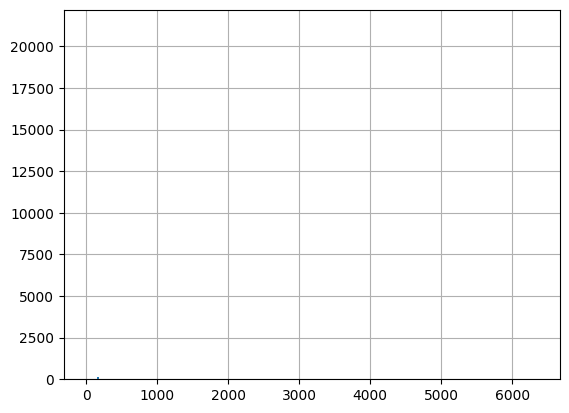

In [3]:
# 6. Distribución de longitud de texto (en palabras) — importante para el EDA de la memoria
df["n_words_full_text"] = df["full_text"].str.split().str.len()
print(df["n_words_full_text"].describe())
df["n_words_full_text"].hist(bins=50000)

In [9]:
# 9. Casos frontera: posts con full_text muy corto (riesgo de poca señal para el modelo)
cortos = df[df["n_words_full_text"] <= 3]
print(f"Posts con 3 palabras o menos: {len(cortos)}")
cortos[["title", "body_text", "domain"]].sample(min(10, len(cortos)), random_state=42)

Posts con 3 palabras o menos: 24301


,title,body_text,domain
106094,Any good?,,clips.twitch.tv
240159,"Reinhardt, REINHARDT, REINHARDT!!",,i.redd.it
107575,Reinhardt Earthshatter bug,,gfycat.com
292937,Double XP?,[deleted],self.Overwatch
51788,lol,,fortnite-gifts.com
221079,"So apparently,",[removed],self.Overwatch
225149,Hammond BM,[deleted],clips.twitch.tv
245160,"Bad Reaper, Bad!",,gfycat.com
142454,Lul!,,youtube.com
163264,I tried..,,i.redd.it


In [10]:
# 8. Distribución de domain — cuántos son link posts (p.ej. i.redd.it, youtube.com) vs self.Overwatch (texto puro)
print(df["domain"].value_counts().head(15))
print("\n% posts con domain distinto de self.Overwatch:",
      (df["domain"] != "self.Overwatch").mean() * 100)

domain
self.Overwatch     152303
gfycat.com          34721
youtube.com         18915
i.redd.it           15581
youtu.be            13452
v.redd.it           12957
clips.twitch.tv      9452
imgur.com            9328
i.imgur.com          3858
streamable.com       3438
twitter.com          2882
twitch.tv            1535
media.giphy.com       703
plays.tv              613
reddit.com            592
Name: count, dtype: int64

% posts con domain distinto de self.Overwatch: 49.23233333333334


ojo! gran parte de los posts tienen un domain externo que no es el del subreddit.

Esto indica que hay ~49% de filas donde es posible que la cantidad de información textual sea pequeña. De todas maneras esto es una simple observación, para futuros pasos en los que necesitemos solo posts con info contextual, se seguirán unas reglas de filtrado algo mas complejas que solo por el domain, ya que aun que el post tenga un gif o un video de youtube, puede tener también una descripción extensa.

okay, a continuación nos disponemos a realizar el analisis td-idf para saber que palabras son las mas caracteristicas dentro de nuestra variable full_text de nuestro subconjunto de datos creado.

In [1]:
import pandas as pd
from sklearn.feature_extraction.text import TfidfVectorizer

# Cargamos el archivo parquet (usamos solo la columna 'full_text' para ahorrar RAM)
df = pd.read_parquet("D:\\TFM\\data\\Overwatch.corpus\\overwatch_posts_final.parquet", columns=['full_text'])

In [14]:
# Inicializamos el vectorizador con optimizaciones
tfidf = TfidfVectorizer(
    stop_words='english',   # Elimina conectores, preposiciones, etc. en inglés
    max_features=10000,     # Nos quedamos solo con las 10,000 palabras más importantes para evitar explotar la RAM
    min_df=5,               # Ignora palabras que aparecen en menos de 5 posts
    max_df=0.7,             # Ignora palabras que aparecen en más del 70% de los posts (demasiado comunes)
    ngram_range=(1, 2)      # Analiza palabras sueltas y frases de dos palabras (ej: "nerf mercy", "competitive queue")
)

# Aplicamos el vectorizador a tu columna 'full_text'
# Esto generará una matriz dispersa (sparse matrix) muy eficiente en memoria
tfidf_matrix = tfidf.fit_transform(df['full_text'].astype(str))

print(f"Matriz TF-IDF creada con dimensiones: {tfidf_matrix.shape}")

Matriz TF-IDF creada con dimensiones: (300000, 10000)


In [15]:
# Obtenemos los nombres de las palabras (features)
feature_names = tfidf.get_feature_names_out()

# Calculamos la media de las puntuaciones TF-IDF para cada palabra (columna) de la matriz
# Usamos mean(axis=0) y lo convertimos a un array plano de numpy
import numpy as np
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

# Creamos un DataFrame para visualizar los resultados
importance_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': mean_tfidf
})

# Ordenamos de mayor a menor peso TF-IDF
top_words = importance_df.sort_values(by='tfidf_score', ascending=False).head(30)

In [17]:
print(top_words)

           word  tfidf_score
2074    deleted     0.042735
7423    removed     0.032128
6110  overwatch     0.020686
3200       game     0.016932
4501       just     0.015275
6537       play     0.012511
4894       like     0.012379
5835        new     0.011965
8711       team     0.011566
5497      mercy     0.010174
3576        got     0.008362
9015       time     0.008211
959    blizzard     0.008183
2356        don     0.007919
6844       potg     0.007904
8908      think     0.007895
3919       hero     0.007797
6347     people     0.007761
4667       know     0.007509
5653      moira     0.007344
9479         ve     0.007337
4125      https     0.007234
3401      genji     0.007227
8072       skin     0.007191
1528        com     0.007076
6692    playing     0.006997
3753      hanzo     0.006902
3540       good     0.006420
9448         va     0.006372
7211     really     0.006353


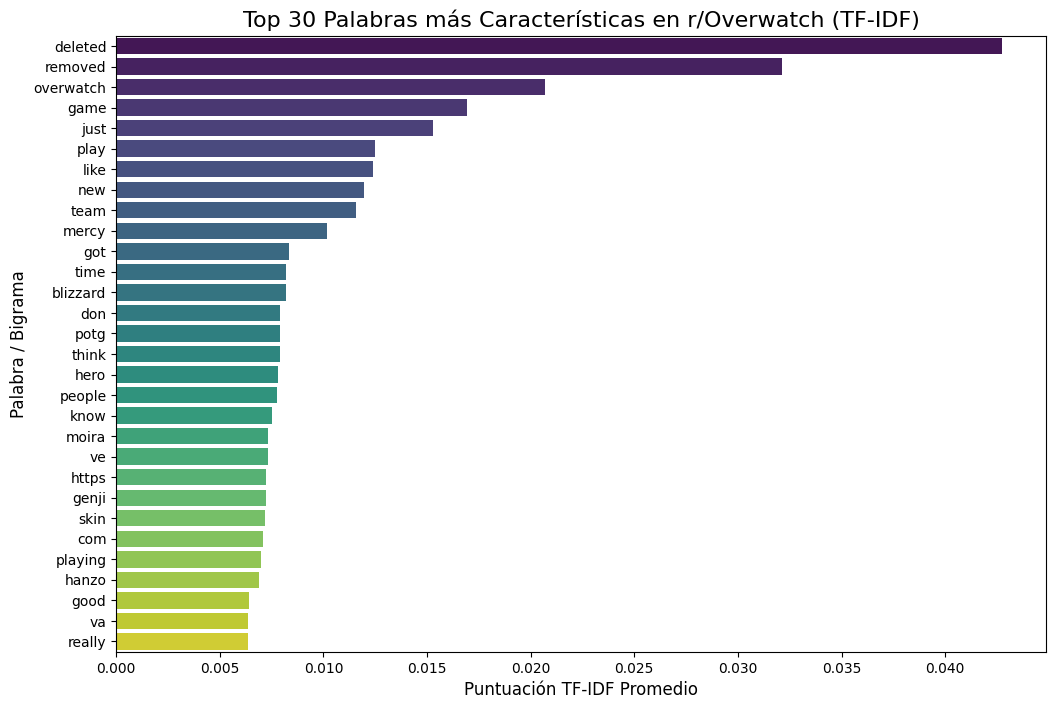

In [16]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 8))
sns.barplot(
    x='tfidf_score', 
    y='word', 
    data=top_words, 
    palette='viridis',
    hue='word',
    legend=False
)
plt.title('Top 30 Palabras más Características en r/Overwatch (TF-IDF)', fontsize=16)
plt.xlabel('Puntuación TF-IDF Promedio', fontsize=12)
plt.ylabel('Palabra / Bigrama', fontsize=12)
plt.show()

okay este analisis td-idf no ha funcionado muy bien.

Para empezar cuando un post o comentario se borra en reddit por el usuario o un moderador aparece el placeholder [removed], o [deleted]. Tenemos que limpiar esos place holders ya que en cualquier subreddit van a aparecer. Luego, hay palabras de vocabulario ingles convencionales que se han colado en el top debido (como a los placeholders) a su volumen masivo. Tambien vemos 'https' o 'com' por el uso de links, vamos a filtrar todo esto.

In [ ]:
import pandas as pd
import re
import numpy as np
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.feature_extraction import text

# ==========================================
# 1. CARGAR DATOS (solo la columna que usaremos)
# ==========================================
df = pd.read_parquet("D:\\TFM\\data\\Overwatch.corpus\\overwatch_posts_final.parquet", columns=['full_text'])
# ==========================================
# 2. FILTRAR POSTS VACÍOS O ELIMINADOS
# ==========================================
# Eliminamos filas que sean literalmente '[deleted]' o '[removed]'
df = df[~df['full_text'].str.contains(r'^\[deleted\]$|^\[removed\]$', case=False, na=True)]

# ==========================================
# 3. LIMPIEZA DE TEXTO (URLs, caracteres, etc.)
# ==========================================
def clean_text(txt):
    if not isinstance(txt, str):
        return ""
    # Convertir a minúsculas
    txt = txt.lower()
    # Eliminar URLs completas (http, https, www)
    txt = re.sub(r'https?://\S+|www\.\S+', '', txt)
    # Eliminar menciones a usuarios y subreddits (u/usuario, r/subreddit)
    txt = re.sub(r'\b[ru]/\S+', '', txt)
    # Conservar solo letras y espacios (eliminamos números, signos de puntuación extraños)
    txt = re.sub(r'[^a-zA-Z\s]', '', txt)
    # Eliminar espacios múltiples en blanco
    txt = re.sub(r'\s+', ' ', txt).strip()
    return txt

print("Limpiando textos (esto puede tardar alrededor de un minuto)...")
df['clean_text'] = df['full_text'].apply(clean_text)

# Volvemos a descartar filas que hayan quedado vacías tras la limpieza
df = df[df['clean_text'] != ""]

# ==========================================
# 4. ENRIQUECER LA LISTA DE STOP WORDS
# ==========================================
# Partimos de las 318 palabras estándar de sklearn
standard_stops = list(text.ENGLISH_STOP_WORDS)

# Añadimos palabras conversacionales y contracciones que la lista estándar no cubre
conversational_stops = [
    'just', 'like', 'really', 'people', 'think', 'know', 'make', 'want', 've', 'don', 'time', 'one', 
    'even', 'someone', 'something', 'anything', 'everyone', 'still', 'good', 'bad', 'much', 'many', 
    'feel', 'say', 'see', 'look', 'back', 'first', 'new', 'going', 'go', 'use', 'way', 'right', 
    'pretty', 'sure', 'well', 'never', 'always', 'every', 'thing', 'things', 'got', 'did', 'does', 
    'doing', 'made', 'makes', 'saying', 'said', 'says', 'thanks', 'thank', 'guy', 'guys',
    'post', 'posts', 'reddit', 'subreddit', 'thread', 'deleted', 'removed', 'amp', 'im', 'cant', 
    'dont', 'didnt', 'ive', 'id', 'ill', 'youre', 'theyre', 'hes', 'shes'
]

# Añadimos palabras genéricas del "contexto de juego" que no aportan valor temático
domain_stops = [
    'game', 'play', 'playing', 'player', 'players', 'hero', 'heroes', 'match', 
    'matches', 'team', 'teams', 'season', 'competitive', 'comp', 'ranked', 'queue', 'lobby',
    'win', 'lose', 'won', 'lost', 'gameplay', 'video', 'clip', 'main'
]

# Combinamos todas las listas de exclusión
custom_stop_words = set(standard_stops + conversational_stops + domain_stops)

# ==========================================
# 5. CONFIGURAR TF-IDF CON PARÁMETROS AGRESIVOS
# ==========================================
tfidf = TfidfVectorizer(
    stop_words=list(custom_stop_words),
    max_features=10000,
    min_df=15,          # La palabra debe aparecer al menos en 15 posts (evita erratas únicas)
    max_df=0.25,        # ¡CLAVE! Si una palabra aparece en más del 25% de los posts se elimina (adiós a palabras ultra-comunes)
    ngram_range=(1, 2)  # Seguirá detectando bigramas interesantes (ej: "battle pass", "loot box")
)

# ==========================================
# 6. ENTRENAR Y MOSTRAR RESULTADOS
# ==========================================
print("Ajustando matriz TF-IDF...")
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

# Extraer términos y puntuación promedio
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

importance_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': mean_tfidf
})

# Ordenamos e imprimimos el top 30 limpio
top_words = importance_df.sort_values(by='tfidf_score', ascending=False).head(30)
print("\n--- TOP 30 PALABRAS MÁS CARACTERÍSTICAS (LIMPIO) ---")
print(top_words.to_string(index=False))

Limpiando textos (esto puede tardar alrededor de un minuto)...
Ajustando matriz TF-IDF...

--- TOP 30 PALABRAS MÁS CARACTERÍSTICAS (LIMPIO) ---
     word  tfidf_score
    mercy     0.010743
 blizzard     0.009099
     potg     0.008483
      dva     0.008169
     skin     0.007782
    genji     0.007511
    hanzo     0.007337
    moira     0.007196
     best     0.007065
    games     0.006604
     kill     0.006257
 brigitte     0.005901
       sr     0.005900
      ana     0.005843
 doomfist     0.005841
   tracer     0.005834
      ult     0.005830
     need     0.005660
reinhardt     0.005548
  getting     0.005502
    widow     0.005483
     help     0.005466
  junkrat     0.005367
   sombra     0.005282
    skins     0.005245
    lucio     0.005191
      bug     0.005142
     love     0.004871
     rein     0.004728
  hammond     0.004709


Esto ya esta mucho mas depurado.

Ahora por rizar un poco el rizo, vamos a hacer un entrenamiento con un modelo que analize combinaciones de 2 o 3 palabras, ya que también podemos extraer una señal bastante distintiva

In [20]:
tfidf = TfidfVectorizer(
    stop_words=list(custom_stop_words),
    max_features=10000,
    min_df=15,          # La palabra debe aparecer al menos en 15 posts (evita erratas únicas)
    max_df=0.25,        # ¡CLAVE! Si una palabra aparece en más del 25% de los posts se elimina (adiós a palabras ultra-comunes)
    ngram_range=(2, 3)  # Seguirá detectando bigramas interesantes (ej: "battle pass", "loot box")
)

# ==========================================
# 6. ENTRENAR Y MOSTRAR RESULTADOS
# ==========================================
print("Ajustando matriz TF-IDF...")
tfidf_matrix = tfidf.fit_transform(df['clean_text'])

# Extraer términos y puntuación promedio
feature_names = tfidf.get_feature_names_out()
mean_tfidf = np.asarray(tfidf_matrix.mean(axis=0)).ravel()

importance_df = pd.DataFrame({
    'word': feature_names,
    'tfidf_score': mean_tfidf
})

# Ordenamos e imprimimos el top 30 limpio
top_words = importance_df.sort_values(by='tfidf_score', ascending=False).head(30)
print("\n--- TOP 30 PALABRAS MÁS CARACTERÍSTICAS (LIMPIO) ---")
print(top_words.to_string(index=False))

Ajustando matriz TF-IDF...

--- TOP 30 PALABRAS MÁS CARACTERÍSTICAS (LIMPIO) ---
                word  tfidf_score
       wrecking ball     0.003649
          loot boxes     0.003009
      blizzard world     0.002459
          voice line     0.002105
          voice chat     0.001968
           world cup     0.001922
            loot box     0.001873
         voice lines     0.001766
           need help     0.001631
         jeff kaplan     0.001613
           high noon     0.001442
        summer games     0.001374
        custom games     0.001371
            dva bomb     0.001306
          pulse bomb     0.001284
       scatter arrow     0.001269
     highlight intro     0.001260
             fan art     0.001250
          golden gun     0.001238
           kings row     0.001232
        free weekend     0.001199
         patch notes     0.001177
          sleep dart     0.001164
        total mayhem     0.001141
literally unplayable     0.001137
       havent played     0.001093
 

Aqui observamos que la mayoría de bigramas son realmente precisos, quiero decir, palabras como 'kings row' o 'sleep dart' son vocabulario bastante específico de overwatch, sin embargo otros bi gramas como 'loot boxes' o 'voice chat', son palabras bastante comúnes, esto supone un problema para la clasificacion final